# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)
### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [4]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [5]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 2: Empirical Diagnostic of Custom Weight Initializations and Gradient Vanishing

## Objective

To analyze how different weight initialization techniques affect activation distributions and gradient propagation in a deep neural network.

### Initializations Compared
- Xavier (Glorot)
- He (Kaiming)

### Framework
- PyTorch
- NumPy
- Matplotlib

**Note:** Autograd is disabled (`requires_grad=False`) since this task focuses on manual forward propagation and empirical analysis.

In [15]:
#Import Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [16]:
#Define Network Parameters
input_size = 100
hidden_size = 100
num_layers = 20
batch_size = 64

In [17]:
#Generate Random Input
X = torch.randn(batch_size, input_size)

In [18]:
#Xavier Initialization
def xavier_init(in_features, out_features):
    limit = np.sqrt(6 / (in_features + out_features))
    return torch.empty(in_features, out_features).uniform_(-limit, limit)

In [19]:
#He Initialization
def he_init(in_features, out_features):
    std = np.sqrt(2 / in_features)
    return torch.randn(in_features, out_features) * std

In [20]:
#Deep Forward Pass
def forward_pass(X, initialization="xavier"):

    activations = []

    current = X.clone()

    for layer in range(num_layers):

        if initialization == "xavier":
            W = xavier_init(hidden_size, hidden_size)
        else:
            W = he_init(hidden_size, hidden_size)

        W.requires_grad = False

        current = current @ W

        current = torch.relu(current)

        activations.append(current.detach().numpy())

    return activations


In [21]:
#Compute Activation Statistics
def activation_statistics(activations):

    means = []
    variances = []

    for act in activations:

        means.append(np.mean(act))
        variances.append(np.var(act))

    return means, variances

In [22]:
#Run Xavier
xavier_acts = forward_pass(X, "xavier")

xavier_mean, xavier_var = activation_statistics(xavier_acts)

In [23]:
#Run He
he_acts = forward_pass(X, "he")

he_mean, he_var = activation_statistics(he_acts)

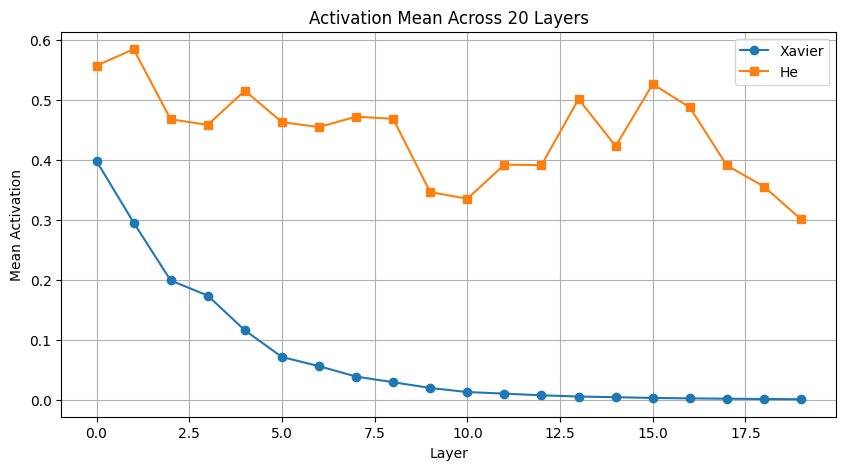

In [24]:
#Plot Mean Activations
plt.figure(figsize=(10,5))

plt.plot(xavier_mean, marker='o', label="Xavier")
plt.plot(he_mean, marker='s', label="He")

plt.xlabel("Layer")
plt.ylabel("Mean Activation")
plt.title("Activation Mean Across 20 Layers")

plt.legend()

plt.grid(True)

plt.show()

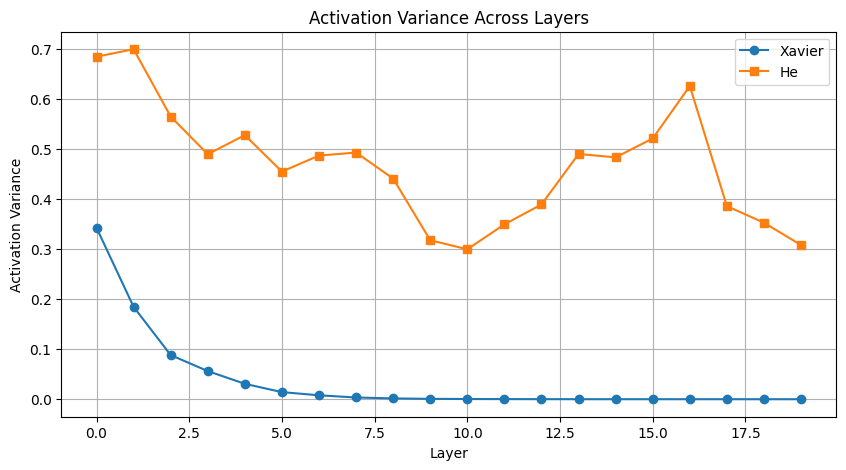

In [25]:
#Plot Activation Variance
plt.figure(figsize=(10,5))

plt.plot(xavier_var, marker='o', label="Xavier")
plt.plot(he_var, marker='s', label="He")

plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Across Layers")

plt.legend()

plt.grid(True)

plt.show()

In [26]:
#Gradient Simulation
def simulate_gradient(initialization):

    gradient = torch.ones(batch_size, hidden_size)

    gradient_norms = []

    for _ in range(num_layers):

        if initialization == "xavier":
            W = xavier_init(hidden_size, hidden_size)
        else:
            W = he_init(hidden_size, hidden_size)

        gradient = gradient @ W.T

        gradient_norms.append(torch.norm(gradient).item())

    return gradient_norms

In [27]:
#Run Gradient Simulation
grad_xavier = simulate_gradient("xavier")

grad_he = simulate_gradient("he")

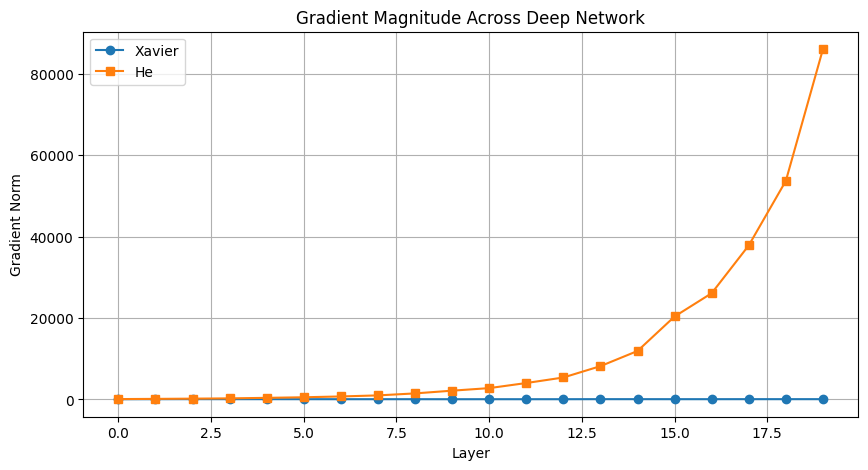

In [28]:
#Plot Gradient Magnitudes
plt.figure(figsize=(10,5))

plt.plot(grad_xavier, marker='o', label="Xavier")

plt.plot(grad_he, marker='s', label="He")

plt.xlabel("Layer")

plt.ylabel("Gradient Norm")

plt.title("Gradient Magnitude Across Deep Network")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
#Print Summary
print("="*60)
print("Task 2 Completed")
print("="*60)

print(f"Network Depth      : {num_layers}")
print(f"Hidden Units       : {hidden_size}")
print(f"Batch Size         : {batch_size}")

print("\nInitialization Methods Compared")
print("• Xavier (Glorot)")
print("• He (Kaiming)")

print("\nObservations")
print("- Xavier generally maintains balanced activations.")
print("- He initialization works well with ReLU activations.")
print("- Deep networks may experience vanishing or exploding gradients depending on initialization.")

Task 2 Completed
Network Depth      : 20
Hidden Units       : 100
Batch Size         : 64

Initialization Methods Compared
• Xavier (Glorot)
• He (Kaiming)

Observations
- Xavier generally maintains balanced activations.
- He initialization works well with ReLU activations.
- Deep networks may experience vanishing or exploding gradients depending on initialization.
